# in vitro endothelium precursors

In [1]:
here::i_am("revisions/06_endothelium_verification/02_characterisation.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”

                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | 

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# MOFA factors
args$mofa = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/celltype_markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata) %>% 
    .[genotype == 'WT' & celltype_v2 %in%  c('HE', 'Allantois')]  # Only WT cells for celltype marker search

In [4]:
table(meta$celltype_v2)


Allantois        HE 
      429      1734 

In [5]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [6]:
rna.sce

class: SingleCellExperiment 
dim: 32285 2163 
metadata(0):
assays(2): counts logcounts
rownames(32285): Xkr4 Gm1992 ... AC234645.1 AC149090.1
rowData names(0):
colnames(2163): 2_Eo_DEG_G9_day3_5_VC#AAACGCGCACCATATG-1
  2_Eo_DEG_G9_day3_5_VC#AAACGGATCTAAATCG-1 ...
  rv_eo_deg_day4_control#TTTGCATTCGCTAGAT-1
  rv_eo_deg_day4_control#TTTGTGTTCCTGAATA-1
colData names(27): barcode sample ... celltype_v1 celltype_v2
reducedDimNames(0):
mainExpName: RNA
altExpNames(0):

In [51]:
DEGs = findMarkers(rna.sce, groups = rna.sce$celltype_v2)

In [52]:
library(Seurat)

In [53]:
seurat = as.Seurat(rna.sce)
Idents(seurat) = seurat@meta.data$celltype_v2
DEGs_seurat = FindMarkers(seurat, ident.1 = 'Allantois')

In [78]:
YS_markers = as.data.table(DEGs_seurat, keep.rownames=T)[avg_log2FC < -0.5 & p_val_adj < 0.05]
allantois_markers = as.data.table(DEGs_seurat, keep.rownames=T)[avg_log2FC > 0.5 & p_val_adj < 0.05]

In [152]:
allantois_markers = allantois_markers[!grep('Hbb|Hba', rn)]

### Load endothelium data

In [154]:
# Load meta
meta = fread(args$metadata) %>% 
    .[celltype_v2 %in%  c('Endothelium')]  # Only WT cells for celltype marker search

In [155]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [156]:
seurat = as.Seurat(rna.sce)

In [157]:
head(allantois_markers)

rn,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Igfbp5,0.000000e+00,1.908616,0.865,0.046,0.000000e+00
Sfrp1,0.000000e+00,1.743059,0.902,0.068,0.000000e+00
Sox6,2.151340e-302,1.908008,0.925,0.108,6.945600e-298
Tbx4,3.915283e-284,1.808206,0.986,0.210,1.264049e-279
Ror1,2.338550e-271,1.907458,0.921,0.153,7.550008e-267
Gm47071,2.351886e-268,1.588408,0.893,0.130,7.593064e-264


In [170]:
top_n = 25
seurat = AddModuleScore(seurat, 
               features = list(allantois = head(allantois_markers[order(-avg_log2FC)]$rn, top_n)),
               name = 'allantois')

seurat = AddModuleScore(seurat, 
               features = list(allantois = head(YS_markers[order(-avg_log2FC)]$rn, top_n)),
               name = 'YS')

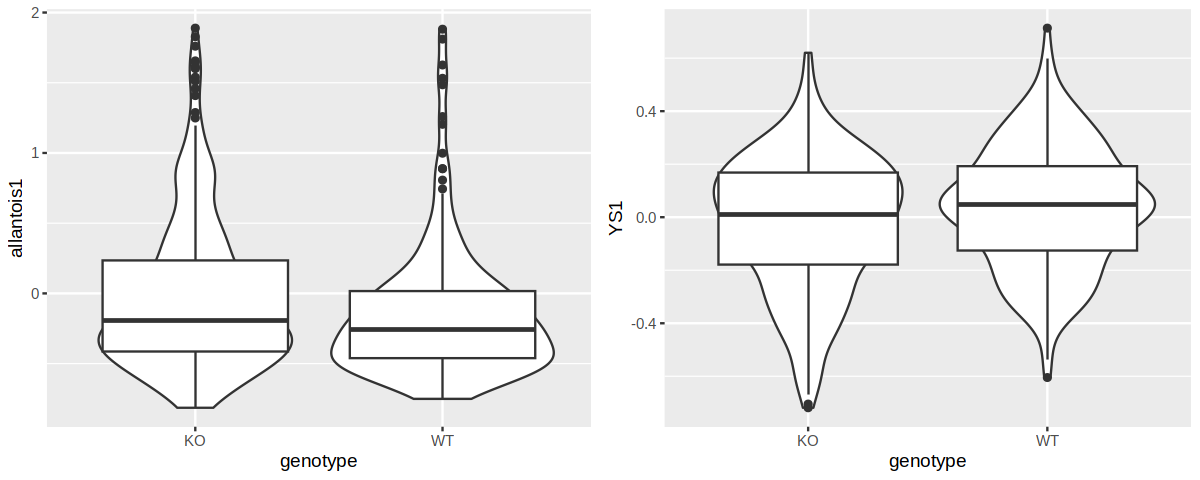

In [171]:
p1 = ggplot(seurat@meta.data, aes(genotype, allantois1)) + 
    geom_violin() + 
    geom_boxplot()

p2 = ggplot(seurat@meta.data, aes(genotype, YS1)) + 
    geom_violin() + 
    geom_boxplot()

options(repr.plot.height=4, repr.plot.width = 10)
ggarrange(p1, p2)

In [172]:

meta$allantois = colMeans(logcounts(rna.sce[head(allantois_markers[order(-avg_log2FC)]$rn, top_n),]))
meta$YS = colMeans(logcounts(rna.sce[head(YS_markers[order(-avg_log2FC)]$rn, top_n),]))


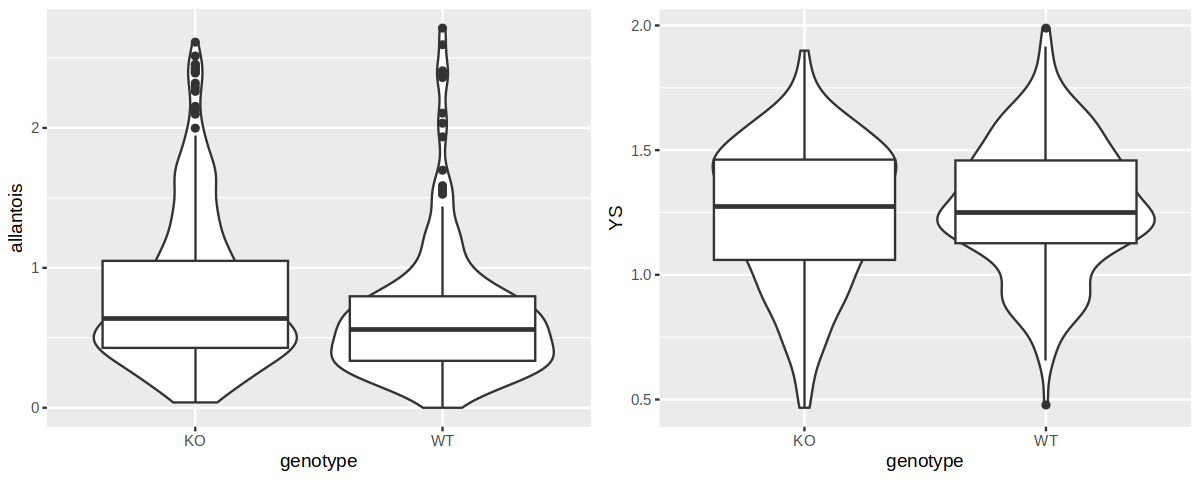

In [173]:
p1 = ggplot(meta, aes(genotype, allantois)) + 
    geom_violin() + 
    geom_boxplot()

p2 = ggplot(meta, aes(genotype, YS)) + 
    geom_violin() + 
    geom_boxplot()

options(repr.plot.height=4, repr.plot.width = 10)
ggarrange(p1, p2)

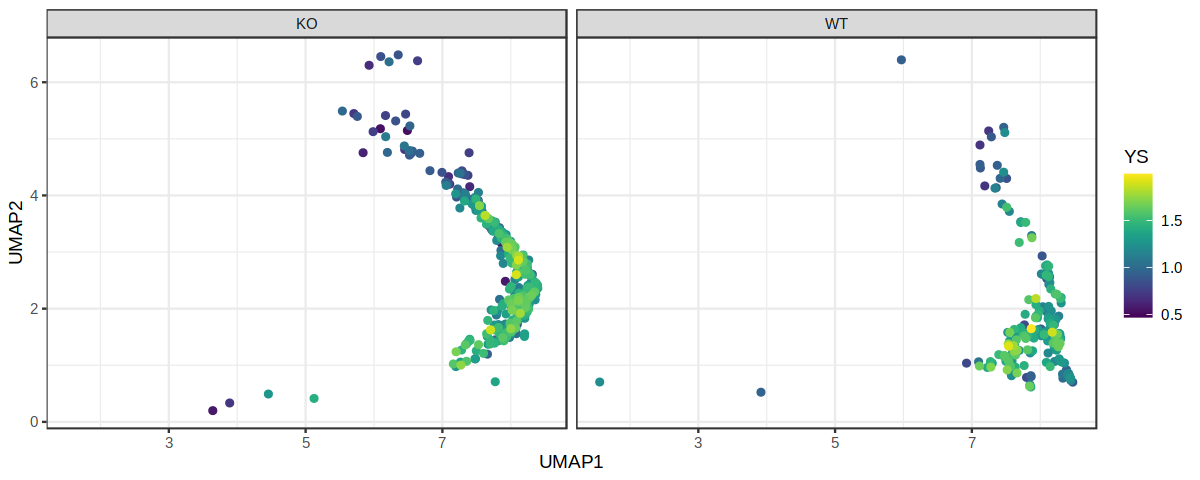

In [174]:
ggplot(meta[order(YS)], aes(UMAP1, UMAP2, col = YS)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw() + 
    facet_wrap(~genotype)

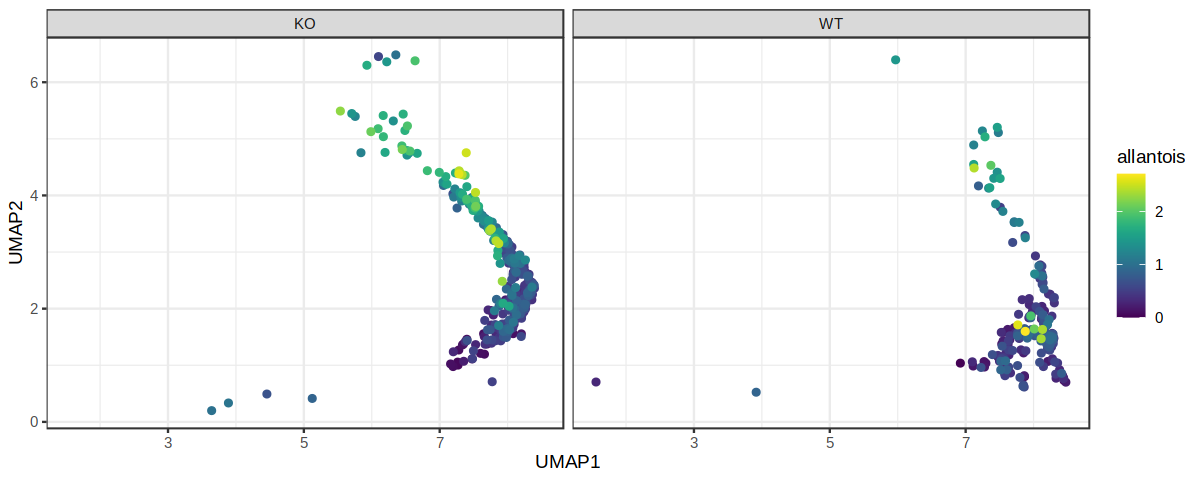

In [175]:
ggplot(meta[order(allantois)], aes(UMAP1, UMAP2, col = allantois)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw() + 
    facet_wrap(~genotype)